In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import factorial

In [2]:
def debye_waller(q, m, w1,w2):
    return q**2/(8*m)*(1/w1+1/w2)

In [3]:
def diagonal_C_true(q, m, w1,w2, n, j, V=1):
    expDebyeWaller = np.exp(-2*debye_waller(q, m, w1,w2))
    c=expDebyeWaller/V * (q**2/(4*m))**n * 1/(factorial(j)*factorial(n-j)*w1**j*w2**(n-j))
    return c

In [4]:
def offDiagonal_C_true(q, m, w1,w2, n, j, V=1, a=0.001):
    expDebyeWaller = np.exp(-2*debye_waller(q, m, w1,w2))
    c=expDebyeWaller/V * (q**2/(4*m))**n * 1/(factorial(j)*factorial(n-j)* w1**j * w2**(n-j))
    if (n-j)%2==1:
        c = -c
    c = c*np.cos(q*2*a)
    return c

In [5]:
def StructureFactorIntegral_true(q, m, w1,w2, n, j, V=1, a=0.001, A=1):
    return 2*A**2*(diagonal_C_true(q, m, w1,w2, n, j, V)+offDiagonal_C_true(q, m, w1,w2, n, j, V, a))

In [38]:
q_values = np.arange(0.5, 500, 0.5)

In [39]:
def StructureFactorIntegral_allj(q, m, w1,w2, n, V=1, a=1, A=1):
    tot=0
    for j in range(n+1):
        tot+=StructureFactorIntegral_true(q, m, w1,w2, n, j, V, a, A)
    return tot

In [40]:
def StructureFactorIntegral_allj_Cross(q, m, w1,w2, n, V=1, a=1, A=1):
    tot=0
    for j in range(n+1):
        tot+=2*A**2*diagonal_C_true(q, m, w1,w2, n, j, V)
    return tot

In [41]:
SFI_allj =[]
SFI_allj_cross = []

SFI_params = {'m':26161, 'w1':1, 'w2':1.5, 'V':10, "A":10, "a":0.1}


for n in range(1,5):
    SFI_allj.append(np.array(
        [StructureFactorIntegral_allj(q, SFI_params['m'], SFI_params['w1'], SFI_params['w2'], n, V=SFI_params['V'], A=SFI_params['A'], a=SFI_params['a']) 
                             for q in q_values]))
    SFI_allj_cross.append(np.array(
        [StructureFactorIntegral_allj_Cross(q, SFI_params['m'], SFI_params['w1'], SFI_params['w2'], n, V=SFI_params['V'], A=SFI_params['A'], a=SFI_params['a']) 
                             for q in q_values]))

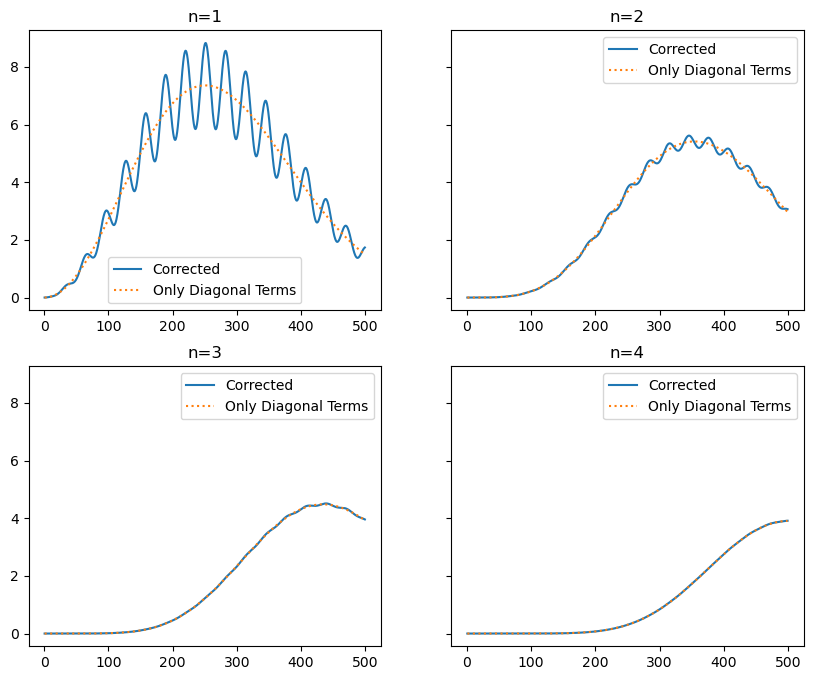

In [42]:
fig, axs = plt.subplots(2, 2, sharey=True, figsize=(10, 8))
for n in range(4):
    axs[int(n/2), n%2].plot(q_values, SFI_allj[n], linewidth=1.5, label = "Corrected")
    axs[int(n/2), n%2].plot(q_values, SFI_allj_cross[n], linewidth=1.5, linestyle = ":", label="Only Diagonal Terms")
    #axs[int((n)/2), n%2].set_yscale('log')
    axs[int((n)/2), n%2].set_title("n="+str(n+1))
    axs[int((n)/2), n%2].legend()